# Benchmark - [Meta's Muse Glimmer 30B](https://huggingface.co/unsloth/Muse-Glimmer-30B-GGUF)

**Evaluation:** Tasks 01-06, excl. 03

**Hardware:** Apple M5 Max 128GB

**Quantization:** UD-Q4_K_XL

In [ ]:
import pandas as pd
from matplotlib import pyplot as plt

from benchmark_lib import (
  DATA_DIR,
  add_token_counts,
  compare_skills,
  latest_batches,
  load_runs,
  metric_table,
  plot_benchmark,
  plot_skill_summary,
  plot_timeouts,
  save_runs,
)

HARDWARE = "Apple M5 Max 128GB"
MODEL_LABEL = "Muse Glimmer 30B"


In [2]:
MODEL_NAME = "Muse-Glimmer-30B-Q4_K_XL"
benchmark_dir = DATA_DIR / "meta" / "muse-glimmer-30b-m5max"

if (not (benchmark_dir / "benchmark.csv").exists()):
  all_runs = load_runs(model=MODEL_NAME, hardware=HARDWARE)
  df = add_token_counts(latest_batches(all_runs))
  save_runs(df, benchmark_dir)


In [3]:
benchmark = pd.read_csv(benchmark_dir / "benchmark.csv")
benchmark["start_time"] = pd.to_datetime(benchmark["start_time"])
benchmark


,task,run,start_time,skills,score,points,total,passed,structure_match,duration_seconds,...,model,harness,model_server,hardware,fields,input_tokens,output_tokens,cache_read_tokens,cache_write_tokens,total_tokens
0,01-data-loading,20260815_003553,2026-08-15 00:35:53.812982,True,1.00,5.0,5,True,True,535,...,Muse-Glimmer-30B-Q4_K_XL,pi,llama.cpp,Apple M5 Max 128GB,"{'n_cells': {'expected': 20857, 'actual': 2085...",12906,13557,575152,0,601615
1,01-data-loading,20260815_004449,2026-08-15 00:44:49.212659,True,1.00,5.0,5,True,True,459,...,Muse-Glimmer-30B-Q4_K_XL,pi,llama.cpp,Apple M5 Max 128GB,"{'n_cells': {'expected': 20857, 'actual': 2085...",33581,9668,724050,0,767299
2,01-data-loading,20260815_005229,2026-08-15 00:52:29.355846,True,1.00,5.0,5,True,True,523,...,Muse-Glimmer-30B-Q4_K_XL,pi,llama.cpp,Apple M5 Max 128GB,"{'n_cells': {'expected': 20857, 'actual': 2085...",14290,12633,521127,0,548050
3,01-data-loading,20260815_010113,2026-08-15 01:01:13.126626,True,1.00,5.0,5,True,True,543,...,Muse-Glimmer-30B-Q4_K_XL,pi,llama.cpp,Apple M5 Max 128GB,"{'n_cells': {'expected': 20857, 'actual': 2085...",10646,13635,632767,0,657048
4,01-data-loading,20260815_011016,2026-08-15 01:10:16.740243,True,1.00,5.0,5,True,True,508,...,Muse-Glimmer-30B-Q4_K_XL,pi,llama.cpp,Apple M5 Max 128GB,"{'n_cells': {'expected': 20857, 'actual': 2085...",14563,12102,616681,0,643346
5,01-data-loading,20260815_011845,2026-08-15 01:18:45.724704,False,1.00,5.0,5,True,True,602,...,Muse-Glimmer-30B-Q4_K_XL,pi,llama.cpp,Apple M5 Max 128GB,"{'n_cells': {'expected': 20857, 'actual': 2085...",16145,14675,898838,0,929658
6,01-data-loading,20260815_012848,2026-08-15 01:28:48.340364,False,1.00,5.0,5,True,True,524,...,Muse-Glimmer-30B-Q4_K_XL,pi,llama.cpp,Apple M5 Max 128GB,"{'n_cells': {'expected': 20857, 'actual': 2085...",8523,13406,444416,0,466345
7,01-data-loading,20260815_013732,2026-08-15 01:37:32.932237,False,0.80,4.0,5,False,True,1186,...,Muse-Glimmer-30B-Q4_K_XL,pi,llama.cpp,Apple M5 Max 128GB,"{'n_cells': {'expected': 20857, 'actual': 2085...",46499,25604,2136101,0,2208204
8,01-data-loading,20260815_015719,2026-08-15 01:57:19.625794,False,1.00,5.0,5,True,True,518,...,Muse-Glimmer-30B-Q4_K_XL,pi,llama.cpp,Apple M5 Max 128GB,"{'n_cells': {'expected': 20857, 'actual': 2085...",34541,10971,888033,0,933545
9,01-data-loading,20260815_020558,2026-08-15 02:05:58.049947,False,1.00,5.0,5,True,True,603,...,Muse-Glimmer-30B-Q4_K_XL,pi,llama.cpp,Apple M5 Max 128GB,"{'n_cells': {'expected': 20857, 'actual': 2085...",14621,14872,790147,0,819640


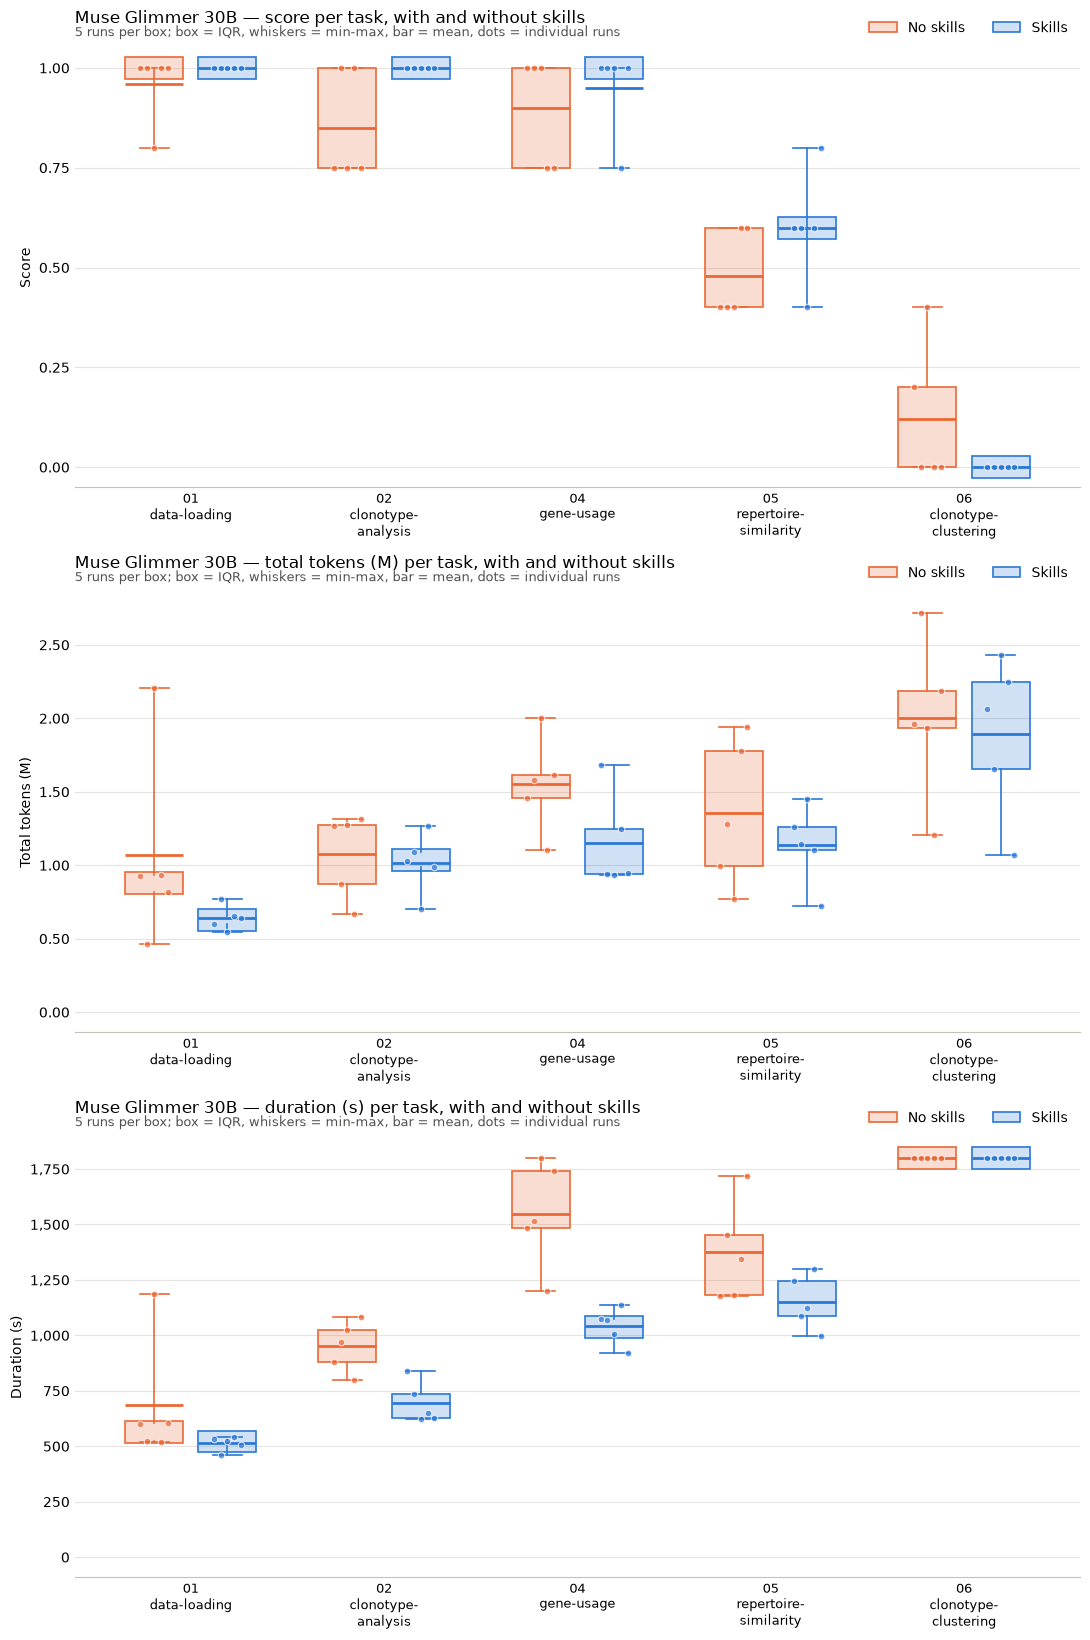

In [4]:
fig, axs = plt.subplots(nrows=3, ncols=1, figsize=(11, 5.5 * 3))
plot_benchmark(benchmark, column="score", model_label=MODEL_LABEL, ax=axs[0])
plot_benchmark(benchmark, column="total_tokens", model_label=MODEL_LABEL, ax=axs[1])
plot_benchmark(benchmark, column="duration_seconds", model_label=MODEL_LABEL, ax=axs[2])
fig.tight_layout()
plt.show()


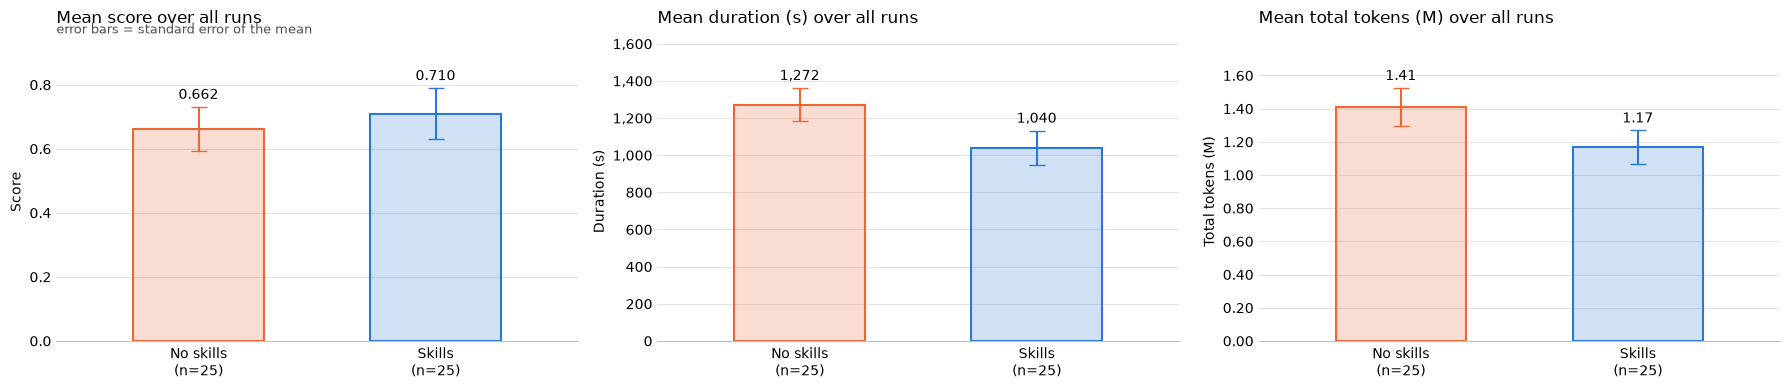

In [5]:
fig, axs = plt.subplots(nrows=1, ncols=3, figsize=(6 * 3, 4))
plot_skill_summary(benchmark, axs=axs)
fig.tight_layout()
plt.show()


In [6]:
significance = compare_skills(benchmark)


In [7]:
metric_table(significance, "score")


,scope,test,n,mean_no_skills,mean_skills,diff,p_value,p_fdr,significant_fdr
0,all tasks (pooled),Mann-Whitney U,25 vs 25,0.662,0.71,0.048,0.383432,NaN,False
1,01-data-loading,Mann-Whitney U,5 vs 5,0.960,1.00,0.040,0.423711,0.529638,False
2,02-clonotype-analysis,Mann-Whitney U,5 vs 5,0.850,1.00,0.150,0.066798,0.333990,False
3,04-gene-usage,Mann-Whitney U,5 vs 5,0.900,0.95,0.050,0.600471,0.600471,False
4,05-repertoire-similarity,Mann-Whitney U,5 vs 5,0.480,0.60,0.120,0.204024,0.340040,False
5,06-clonotype-clustering,Mann-Whitney U,5 vs 5,0.120,0.00,-0.120,0.179712,0.340040,False
6,all tasks (paired by task),Wilcoxon signed-rank,5 tasks,0.662,0.71,0.048,0.437500,NaN,False


In [8]:
metric_table(significance, "duration_seconds")


,scope,test,n,mean_no_skills,mean_skills,diff,p_value,p_fdr,significant_fdr
0,all tasks (pooled),Mann-Whitney U,25 vs 25,1272.12,1039.92,-232.2,0.099748,NaN,False
1,01-data-loading,Mann-Whitney U,5 vs 5,686.60,513.60,-173.0,0.150794,0.188492,False
2,02-clonotype-analysis,Mann-Whitney U,5 vs 5,951.20,694.20,-257.0,0.015873,0.039683,True
3,04-gene-usage,Mann-Whitney U,5 vs 5,1547.80,1041.60,-506.2,0.007937,0.039683,True
4,05-repertoire-similarity,Mann-Whitney U,5 vs 5,1375.00,1150.20,-224.8,0.095238,0.158730,False
5,06-clonotype-clustering,Mann-Whitney U,5 vs 5,1800.00,1800.00,0.0,1.000000,1.000000,False
6,all tasks (paired by task),Wilcoxon signed-rank,5 tasks,1272.12,1039.92,-232.2,0.125000,NaN,False


In [9]:
metric_table(significance, "total_tokens")


,scope,test,n,mean_no_skills,mean_skills,diff,p_value,p_fdr,significant_fdr
0,all tasks (pooled),Mann-Whitney U,25 vs 25,1411491.08,1167024.12,-244466.96,0.099098,NaN,False
1,01-data-loading,Mann-Whitney U,5 vs 5,1071478.40,643471.60,-428006.80,0.150794,0.376984,False
2,02-clonotype-analysis,Mann-Whitney U,5 vs 5,1079948.80,1015243.40,-64705.40,0.547619,0.684524,False
3,04-gene-usage,Mann-Whitney U,5 vs 5,1552120.60,1148105.20,-404015.40,0.150794,0.376984,False
4,05-repertoire-similarity,Mann-Whitney U,5 vs 5,1352748.60,1135792.00,-216956.60,0.547619,0.684524,False
5,06-clonotype-clustering,Mann-Whitney U,5 vs 5,2001159.00,1892508.40,-108650.60,1.000000,1.000000,False
6,all tasks (paired by task),Wilcoxon signed-rank,5 tasks,1411491.08,1167024.12,-244466.96,0.062500,NaN,False


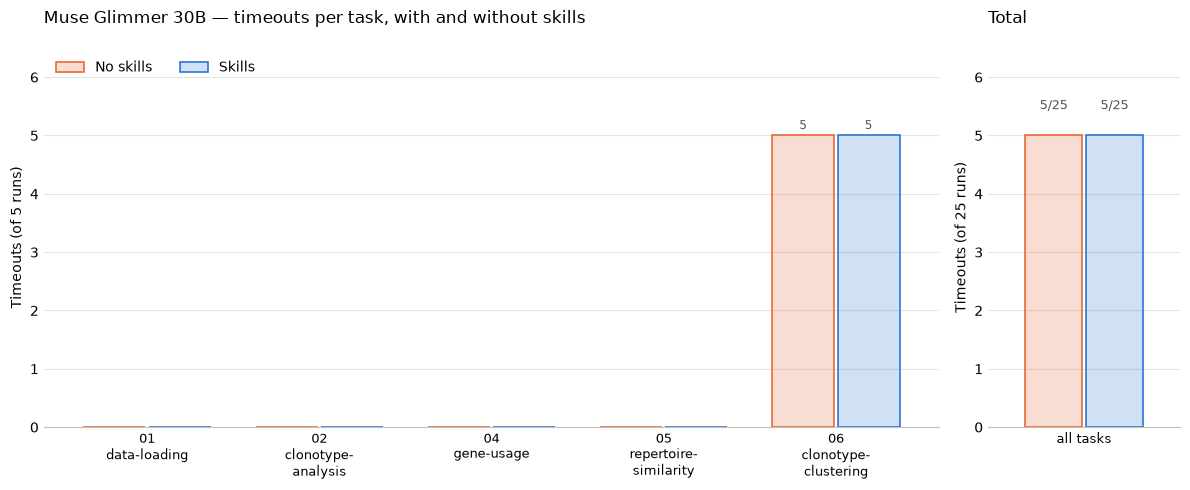

In [10]:
fig, axs = plt.subplots(1, 2, figsize=(12, 5), gridspec_kw={"width_ratios": [7, 1.5]})
plot_timeouts(benchmark, model_label=MODEL_LABEL, axs=axs)
fig.tight_layout()
plt.show()
